# Predicting Fit Success for Custom Footwear using Machine Learning

## Project Objective

The objective of this project is to predict whether a shoe will fit a customer successfully before production.

This project simulates how foot scan data and product-related features can be used to support data-driven decision-making in custom footwear manufacturing systems.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

## 2. Create Synthetic Dataset

Since real-world foot scan data is not publicly available, a synthetic dataset is created to simulate customer foot measurements and product-related features.

The dataset includes variables such as foot length, foot width, arch height, instep height, asymmetry between feet, pressure points, and shoe design type.

These features are chosen to represent factors that may influence how well a shoe fits a customer.

In [2]:
np.random.seed(42)
n = 1000

data = pd.DataFrame({
    "foot_length": np.random.normal(26, 2, n),
    "foot_width": np.random.normal(10, 1, n),
    "arch_height": np.random.normal(6, 1.5, n),
    "instep_height": np.random.normal(7, 1, n),
    "asymmetry": np.random.uniform(0, 2, n),
    "pressure_points": np.random.randint(0, 5, n),
    "design_type": np.random.choice([0,1,2], n)
})

## 3. Create Target Variable (Fit Success)

The target variable in this project is "Fit_success".

- A value of **1** represents a successful fit (comfortable and well-fitting shoe)
- A value of **0** represents an unsuccessful fit (poor comfort or fit issues)

Since real customer feedback data is not available, the target variable is generated using logical assumptions based on foot characteristics.

Factors such as low asymmetry, fewer pressure points, and balanced foot structure are assumed to increase the likelihood of a successful fit.

In [3]:
def generate_satisfaction(row):
    score = 0

    if 25 <= row["foot_length"] <= 28:
        score += 1
    if row["asymmetry"] < 1:
        score += 1
    if row["pressure_points"] < 2:
        score += 1
    if row["arch_height"] > 5:
        score += 1

    return 1 if score >= 3 else 0

data["fit_success"] = data.apply(generate_satisfaction, axis=1)

In [4]:
data.head()

,foot_length,foot_width,arch_height,instep_height,asymmetry,pressure_points,design_type,fit_success
0,26.993428,11.399355,4.987233,5.092192,0.970036,1,1,1
1,25.723471,10.924634,5.783222,6.139615,0.170806,4,1,1
2,27.295377,10.059630,4.811370,6.586394,1.944923,4,1,0
3,29.046060,9.353063,5.538058,8.887688,1.036021,0,1,0
4,25.531693,10.698223,3.159578,7.556553,1.228372,2,0,0


In [5]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   foot_length      1000 non-null   float64
 1   foot_width       1000 non-null   float64
 2   arch_height      1000 non-null   float64
 3   instep_height    1000 non-null   float64
 4   asymmetry        1000 non-null   float64
 5   pressure_points  1000 non-null   int64  
 6   design_type      1000 non-null   int64  
 7   fit_success      1000 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 62.6 KB


,foot_length,foot_width,arch_height,instep_height,asymmetry,pressure_points,design_type,fit_success
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,26.038664,10.070836,6.008751,6.981281,0.998305,1.942000,0.967000,0.396000
std,1.958432,0.997454,1.475181,1.027133,0.580321,1.408055,0.823765,0.489309
min,19.517465,7.059611,1.470732,4.070551,0.012368,0.000000,0.000000,0.000000
25%,24.704819,9.393758,5.028001,6.262580,0.491455,1.000000,0.000000,0.000000
50%,26.050601,10.063077,5.999624,7.000185,0.982948,2.000000,1.000000,0.000000
75%,27.295888,10.728882,6.991373,7.666945,1.507627,3.000000,2.000000,1.000000
max,33.705463,13.193108,11.889357,10.243093,1.998701,4.000000,2.000000,1.000000


In [6]:
data.to_csv("foot_data.csv", index=False)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
## Project Objective
##Predict whether a 3D-printed shoe will fit a customer based on foot scan data.

## Variables
##- foot_length: length of foot
##- asymmetry: difference between left and right foot
##- pressure_points: discomfort zones
##- fit_success: target variable (1 = good fit, 0 = bad fit)

## 4. Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

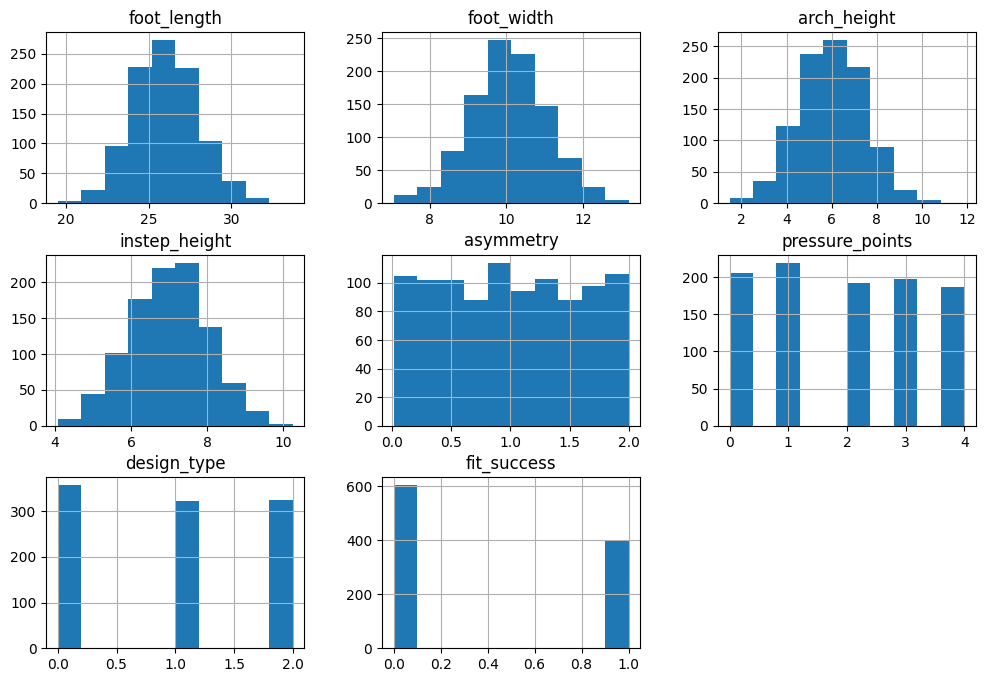

In [10]:
data.hist(figsize=(12, 8))
plt.show()

Observation:
Most foot measurements follow a normal distribution.
Pressure points are discrete values.
No extreme outliers observed.

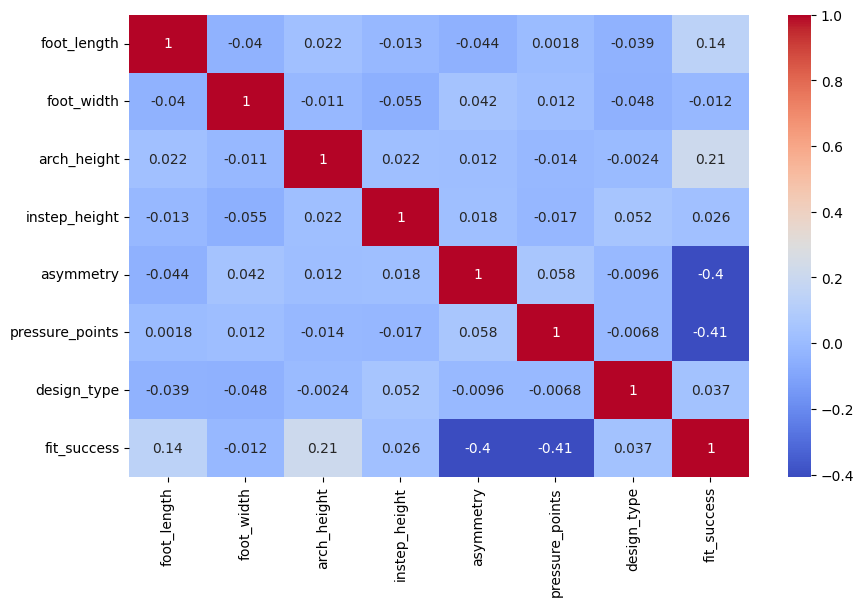

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

Observation:
Asymmetry and pressure points show negative correlation with fit success, indicating that higher values reduce the likelihood of a good fit.

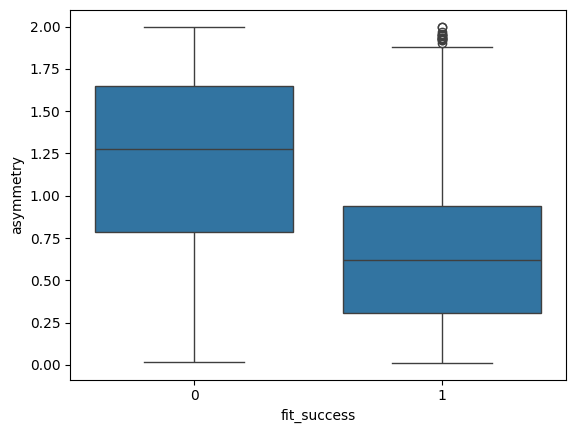

In [12]:
sns.boxplot(x="fit_success", y="asymmetry", data=data)
plt.show()

Observation:
Customers with higher asymmetry tend to have lower fit success.

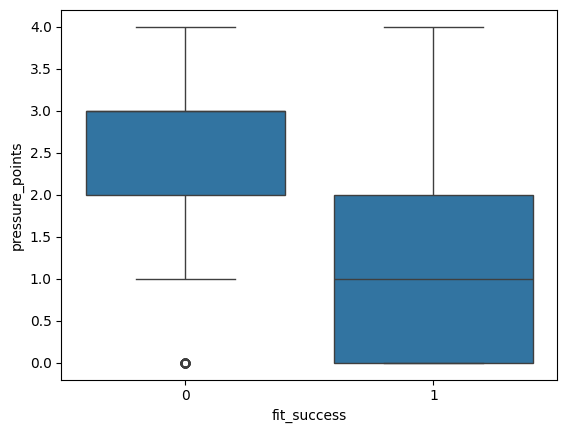

In [13]:
sns.boxplot(x="fit_success", y="pressure_points", data=data)
plt.show()

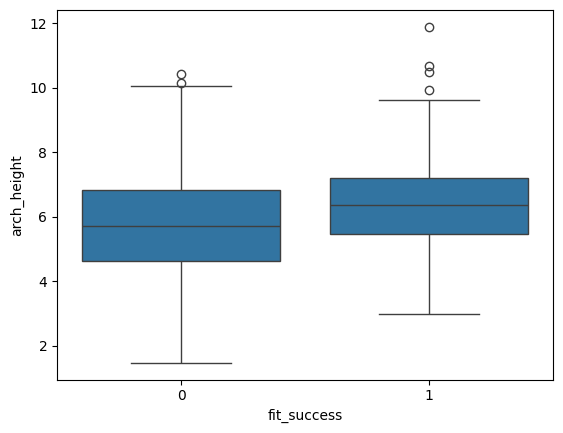

In [14]:
sns.boxplot(x="fit_success", y="arch_height", data=data)
plt.show()

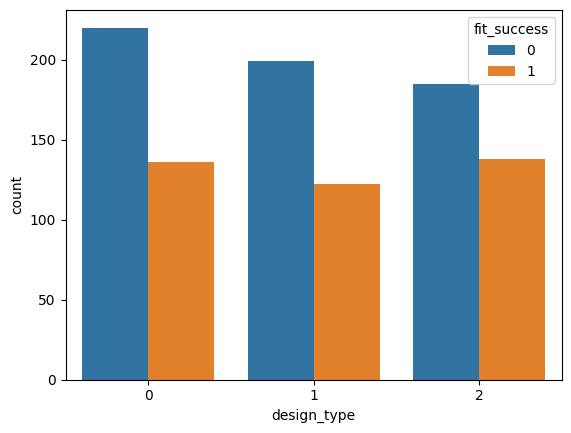

In [15]:
sns.countplot(x="design_type", hue="fit_success", data=data)
plt.show()

In [16]:
data["fit_success"].value_counts()

,count
fit_success,
0,604
1,396


Key Insights:

1. Higher asymmetry significantly reduces fit success.
2. Increased pressure points are strongly associated with poor fit.
3. Moderate arch height improves comfort and fit.
4. Shoe design type may influence fit outcomes.

These findings suggest that foot symmetry and pressure distribution are critical factors in predicting successful footwear fitting.

## 5. Model Building

In this step, a machine learning model is trained to predict whether a shoe will result in a successful fit.

The independent variables include foot measurements and design-related features, while the dependent variable is "fit_success".

A Random Forest classifier is used because it can capture complex, nonlinear relationships between features and is well-suited for tabular data.

The dataset is split into training and testing sets to evaluate how well the model performs on unseen data.

In [18]:
X = data.drop("fit_success", axis=1)
y = data["fit_success"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.995
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       118
           1       1.00      0.99      0.99        82

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



## 7. Feature Importance

In [23]:
importance = model.feature_importances_

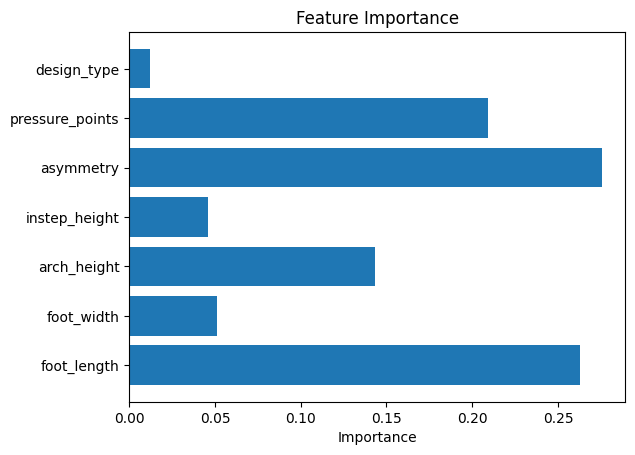

In [24]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

Feature Importance Insight:

The model identifies asymmetry and pressure points as the most important factors influencing fit success.
This suggests that foot balance and discomfort zones play a critical role in determining whether a shoe will fit well.

In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Random Forest Accuracy: 0.995
Logistic Regression Accuracy: 0.81


Model Comparison:

Random Forest outperforms Logistic Regression, indicating that the relationship between foot features and fit success is nonlinear and better captured by tree-based models.

## 8. Fit Risk Score

Instead of only predicting whether a fit is good or bad, the model also provides a probability score.

This probability is converted into a **Fit Risk Score**, which represents the likelihood of a successful fit.

This allows the prediction to be used in a practical decision-making context.

Decision logic:

- **Above 80%** → Safe to proceed with production  
- **50% to 80%** → Fit is uncertain, may require adjustments  
- **Below 50%** → High risk of poor fit, should be reviewed before production  

This approach transforms a machine learning prediction into an actionable business tool.

In [27]:
import pandas as pd

new_customer = pd.DataFrame({
    "foot_length": [27],
    "foot_width": [10],
    "arch_height": [6],
    "instep_height": [7],
    "asymmetry": [0.5],
    "pressure_points": [1],
    "design_type": [0]
})

In [28]:
prob = model.predict_proba(new_customer)[0][1]
risk_score = prob * 100

print(f"Fit Score: {risk_score:.2f}%")

if risk_score > 80:
    print("✅ Safe to print")
elif risk_score > 50:
    print("⚠️ Needs adjustment")
else:
    print("❌ High risk – redesign needed")

Fit Score: 99.00%
✅ Safe to print


Customers with high predicted fit scores can proceed directly to production.
Medium scores may require design adjustments, while low scores indicate a high risk of poor fit and should be reviewed before manufacturing.

Business Application:

The Fit Risk Score translates model predictions into actionable decisions.
It enables manufacturers to evaluate fit success before production, reducing waste, improving customer satisfaction, and optimizing on-demand manufacturing processes.

## 9. Conclusion

This project demonstrates how machine learning can be used to predict product performance before manufacturing.

Using simulated foot scan data, the model identifies key factors that influence whether a shoe will fit successfully, such as asymmetry and pressure points.

The introduction of a Fit Risk Score allows predictions to be translated into actionable decisions, helping reduce production risk, improve customer satisfaction, and optimize on-demand manufacturing processes.

This approach highlights how data analytics can bridge the gap between digital design and physical product performance in custom manufacturing systems.